<a href="https://colab.research.google.com/github/2303A52014/aiac_2014/blob/main/aiac.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install python-pptx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 16.9 MB/s eta 0:00:00


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.8 MB/s eta 0:00:00


In [ ]:
!pip install deepface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.6 MB/s eta 0:00:00


In [ ]:
def detect_and_identify(self, frame):
    results = self.model(frame, conf=0.4, verbose=False)
    detections = []
    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            face_crop       = frame[y1:y2, x1:x2]
            if face_crop.size == 0:
                continue
            sid, conf = self.identify(face_crop)
            detections.append({
                "bbox":       (x1, y1, x2, y2),
                "student_id": sid,
                "confidence": conf
            })
    return detections

In [ ]:
import cv2
import numpy as np
import os
import pickle
from ultralytics import YOLO
from deepface import DeepFace

MODEL_PATH  = "yolov8n.pt" # Changed from "yolov8n-face.pt"
DB_PATH     = "student_faces/"
EMBED_FILE  = "embeddings.pkl"
THRESHOLD   = 0.6

class FaceRecognizer:
    def __init__(self):
        self.model      = YOLO(MODEL_PATH)
        self.embeddings = self._load_embeddings()

    def _load_embeddings(self):
        if os.path.exists(EMBED_FILE):
            with open(EMBED_FILE, "rb") as f:
                return pickle.load(f)
        return {}

    def register_student(self, student_id, image_path):
        """Register a new student face into the database."""
        img = cv2.imread(image_path)
        emb = DeepFace.represent(
            img, model_name="Facenet",
            enforce_detection=False
            )[0]["embedding"]
        self.embeddings[student_id] = np.array(emb)
        with open(EMBED_FILE, "wb") as f:
            pickle.dump(self.embeddings, f)
        print(f"Registered: {student_id}")

    def _cosine_similarity(self, a, b):
        return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

    def identify(self, face_crop):
        """Identify a face crop and return (student_id, confidence)."""
        try:
            emb = DeepFace.represent(
                face_crop, model_name="Facenet",
                enforce_detection=False
            )[0]["embedding"]
            emb = np.array(emb)
        except Exception:
            return "Unknown", 0.0

        best_id, best_score = "Unknown", 0.0
        for sid, stored_emb in self.embeddings.items():
            score = self._cosine_similarity(emb, stored_emb)
            if score > best_score:
                best_score = score
                best_id    = sid

        if best_score < THRESHOLD:
            return "Unknown", float(best_score)
        return best_id, float(best_score)

    def detect_and_identify(self, frame):
        """
        Run YOLOv8 face detection on a frame.
        Returns list of dicts: {bbox, student_id, confidence}
        """
        results = self.model(frame, conf=0.4, verbose=False)
        detections = []
        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                face_crop       = frame[y1:y2, x1:x2]
                if face_crop.size == 0:
                    continue
                sid, conf = self.identify(face_crop)
                detections.append({
                    "bbox":       (x1, y1, x2, y2),
                    "student_id": sid,
                    "confidence": conf
                })
        return detections

    def draw_detections(self, frame, detections):
        """Draw bounding boxes and labels on the frame."""
        for d in detections:
            x1, y1, x2, y2 = d["bbox"]
            color = (0, 200, 0) if d["student_id"] != "Unknown" else (0, 0, 200)
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            label = f"{d['student_id']} ({d['confidence']:.2f})"
            cv2.putText(frame, label, (x1, y1 - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)
        return frame

In [ ]:
recognizer = FaceRecognizer()
print("FaceRecognizer initialized.")

FaceRecognizer initialized.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Image loaded successfully from /passphoto.vidya.jpg
26-04-19 18:01:30 - 🔗 facenet_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5 to /root/.deepface/weights/facenet_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5
To: /root/.deepface/weights/facenet_weights.h5
100%|██████████| 92.2M/92.2M [00:00<00:00, 103MB/s]


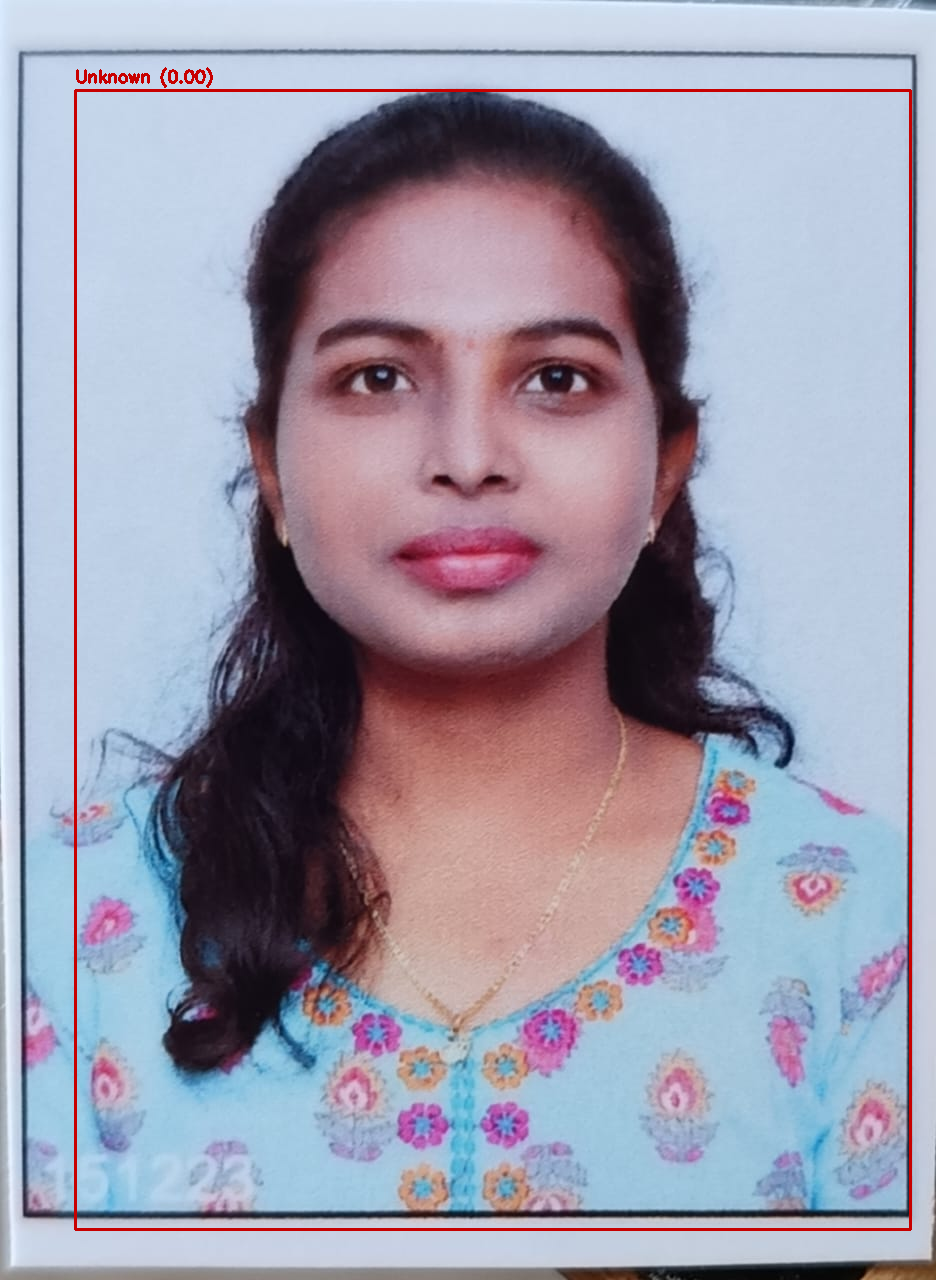

In [ ]:
from google.colab.patches import cv2_imshow

# Load a sample image
image_path = "/passphoto.vidya.jpg" # You can change this to another image path
img = cv2.imread(image_path)

if img is None:
    print(f"Error: Image not found at {image_path}")
else:
    print(f"Image loaded successfully from {image_path}")
    # Detect and identify faces in the image
    detections = recognizer.detect_and_identify(img)

    # Draw the detections on the image
    img_with_detections = recognizer.draw_detections(img.copy(), detections)

    # Display the image with detections
    cv2_imshow(img_with_detections)